# 01 — Khám phá dữ liệu VLSP2018 ABSA Restaurant

Notebook này dùng để **khám phá nhằm hiểu dữ liệu trước khi train model NLP**

Mục tiêu:
- Kiểm tra cấu trúc dataset;
- Thống kê số lượng train/dev/test;
- Phân tích phân bố aspect và polarity;
- Phát hiện mất cân bằng nhãn;
- Rút ra nhận xét vì sao model ABSA cần xử lý cẩn thận bước tiền xử lý

> Bài toán của đồ án: với mỗi review, model cần phát hiện các **aspect** (khía cạnh) được nhắc tới và dự đoán cảm xúc tương ứng: `none`, `positive`, `negative`, `neutral`.

## 1. Khởi tạo môi trường

Cell này tự tìm thư mục gốc project `Food_Review_NLP`, thêm vào `sys.path`, rồi chuẩn bị các hàm đọc dữ liệu

In [1]:
from __future__ import annotations

import json
import re
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

def find_project_root() -> Path:
    """Tự tìm thư mục gốc project: nơi có src/ và data/."""
    cur = Path.cwd().resolve()
    for p in [cur, *cur.parents]:
        if (p / "src").exists() and (p / "data").exists():
            return p
    # fallback khi chạy notebook trong thư mục notebooks/
    if cur.name.lower() == "notebooks":
        return cur.parent
    return cur

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

try:
    from src import config as project_config
except Exception:
    project_config = None

def get_path_config(name: str, default: Path) -> Path:
    """Lấy path từ src.config nếu có, nếu không dùng default"""
    cfg = getattr(project_config, "CONFIG", None) if project_config is not None else None
    path_cfg = getattr(cfg, "path", None)
    value = getattr(path_cfg, name, None) if path_cfg is not None else None
    return Path(value) if value else default

RAW_DIR = get_path_config("raw_dir", PROJECT_ROOT / "data" / "raw")
PROCESSED_DIR = get_path_config("processed_dir", PROJECT_ROOT / "data" / "processed")
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

print("RAW_DIR:", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)

PROJECT_ROOT: C:\Users\ADMIN\Downloads\Food_Review_NLP
RAW_DIR: C:\Users\ADMIN\Downloads\Food_Review_NLP\data\raw
PROCESSED_DIR: C:\Users\ADMIN\Downloads\Food_Review_NLP\data\processed


## 2. Đọc dữ liệu

Dataset gốc nằm ở `data/raw/VLSP2018-ABSA-Restaurant.csv`.  
Nếu đã chạy pipeline, dữ liệu sau tiền xử lý sẽ nằm ở `data/processed/*.parquet`.

In [2]:
SUPPORTED_EXT = {".csv", ".parquet", ".json", ".jsonl", ".xlsx", ".xls"}

def read_table(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == ".csv":
        try:
            return pd.read_csv(path, encoding="utf-8")
        except UnicodeDecodeError:
            return pd.read_csv(path, encoding="utf-8-sig")
    if suffix == ".parquet":
        return pd.read_parquet(path)
    if suffix == ".json":
        return pd.read_json(path)
    if suffix == ".jsonl":
        return pd.read_json(path, lines=True)
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(f"Không hỗ trợ định dạng: {path}")

def load_folder(folder: Path) -> pd.DataFrame:
    files = sorted([p for p in folder.glob("*") if p.suffix.lower() in SUPPORTED_EXT])
    frames = []
    for path in files:
        try:
            df = read_table(path)
            df["_source_file"] = path.name
            frames.append(df)
        except Exception as exc:
            print(f"[WARN] Bỏ qua {path.name}: {exc}")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

raw_df = load_folder(RAW_DIR)
processed_df = load_folder(PROCESSED_DIR) if PROCESSED_DIR.exists() else pd.DataFrame()

print(f"Raw shape      : {raw_df.shape}")
print(f"Processed shape: {processed_df.shape}")

display(raw_df.head(3))

Raw shape      : (4751, 16)
Processed shape: (4751, 18)


,Review,AMBIENCE#GENERAL,DRINKS#PRICES,DRINKS#QUALITY,DRINKS#STYLE&OPTIONS,FOOD#PRICES,FOOD#QUALITY,FOOD#STYLE&OPTIONS,LOCATION#GENERAL,RESTAURANT#GENERAL,RESTAURANT#MISCELLANEOUS,RESTAURANT#PRICES,SERVICE#GENERAL,type,dataset,_source_file
0,"_ Ảnh chụp từ hôm qua, đi chơi với gia đình và 1 nhà họ hàng đang sống tại Sài Gòn. _ Hôm qua đi ăn trưa muộn, ai cũ...",0,0,0,0,0,3,3,0,0,0,0,0,train,VLSP2018-ABSA-Restaurant,VLSP2018-ABSA-Restaurant.csv
1,"_Hương vị thơm ngon, ăn cay cay rất thích, nêm nếm vừa miệng. Ngoài ra menu quán cũng nhiều món khác nhau tha hồ cho...",1,0,0,0,3,1,1,0,1,0,3,2,train,VLSP2018-ABSA-Restaurant,VLSP2018-ABSA-Restaurant.csv
2,"- 1 bàn tiệc hoành tráng 3 đứa ăn no muốn tắt thở mà giá chỉ 228k (ăn trung đợt giảm 10%), mình thích nhất pad thái ...",2,0,0,0,1,1,1,2,1,1,0,1,train,VLSP2018-ABSA-Restaurant,VLSP2018-ABSA-Restaurant.csv


## 3. Nhận diện cột review và cột aspect

Trong VLSP2018 ABSA Restaurant:
- `Review`: nội dung review;
- Các cột dạng `ENTITY#ATTRIBUTE`: nhãn aspect;
- `type`: split dữ liệu, gồm `train`, `dev`, `test`

Mã nhãn:
- `0 = none`: aspect không được nhắc tới;
- `1 = positive`;
- `2 = negative`;
- `3 = neutral`.

In [3]:
LABEL_NAMES = {
    0: "none",
    1: "positive",
    2: "negative",
    3: "neutral",
}

def guess_text_column(df: pd.DataFrame) -> str | None:
    candidates = ["Review", "review", "text", "comment", "content", "phobert_text"]
    for c in candidates:
        if c in df.columns:
            return c
    return None

def get_aspect_columns(df: pd.DataFrame) -> list[str]:
    return [c for c in df.columns if "#" in str(c)]

df = processed_df if not processed_df.empty else raw_df
text_col = guess_text_column(df)
aspect_cols = get_aspect_columns(df)

print("Text column:", text_col)
print("Số aspect:", len(aspect_cols))
print(aspect_cols)

schema_rows = []
for col in df.columns:
    schema_rows.append({
        "column": col,
        "dtype": str(df[col].dtype),
        "missing": int(df[col].isna().sum()),
        "unique": int(df[col].nunique(dropna=True)),
    })
display(pd.DataFrame(schema_rows))

Text column: Review
Số aspect: 12
['AMBIENCE#GENERAL', 'DRINKS#PRICES', 'DRINKS#QUALITY', 'DRINKS#STYLE&OPTIONS', 'FOOD#PRICES', 'FOOD#QUALITY', 'FOOD#STYLE&OPTIONS', 'LOCATION#GENERAL', 'RESTAURANT#GENERAL', 'RESTAURANT#MISCELLANEOUS', 'RESTAURANT#PRICES', 'SERVICE#GENERAL']


,column,dtype,missing,unique
0,Review,str,0,4711
1,AMBIENCE#GENERAL,int64,0,4
2,DRINKS#PRICES,int64,0,4
3,DRINKS#QUALITY,int64,0,4
4,DRINKS#STYLE&OPTIONS,int64,0,4
5,FOOD#PRICES,int64,0,4
6,FOOD#QUALITY,int64,0,4
7,FOOD#STYLE&OPTIONS,int64,0,4
8,LOCATION#GENERAL,int64,0,4
9,RESTAURANT#GENERAL,int64,0,4


## 4. Thống kê tổng quan dataset

Kiểm tra dữ liệu trước khi xây dựng mô hình

,Thông tin,Giá trị
0,Số dòng,4751
1,Số cột,18
2,Cột review,Review
3,Số aspect,12
4,Số file nguồn,1


,split,count,ratio
0,train,2961,0.623237
1,dev,1290,0.271522
2,test,500,0.105241


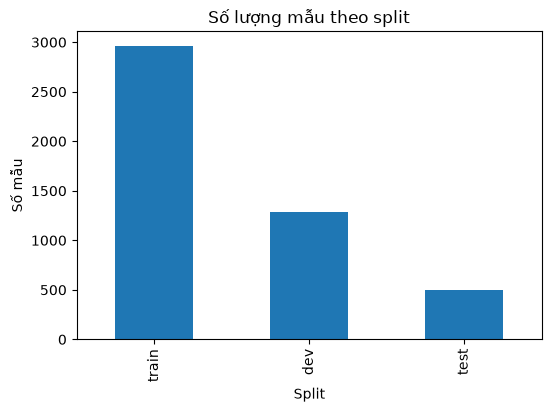

In [4]:
summary = {
    "Số dòng": len(df),
    "Số cột": df.shape[1],
    "Cột review": text_col,
    "Số aspect": len(aspect_cols),
    "Số file nguồn": df["_source_file"].nunique() if "_source_file" in df.columns else 1,
}
display(pd.DataFrame(summary.items(), columns=["Thông tin", "Giá trị"]))

if "type" in df.columns:
    split_counts = df["type"].value_counts().rename_axis("split").reset_index(name="count")
    split_counts["ratio"] = split_counts["count"] / split_counts["count"].sum()
    display(split_counts)

    ax = split_counts.plot(x="split", y="count", kind="bar", legend=False, figsize=(6, 4))
    ax.set_title("Số lượng mẫu theo split")
    ax.set_xlabel("Split")
    ax.set_ylabel("Số mẫu")
    plt.show()

## 5. Phân bố độ dài review

Độ dài review ảnh hưởng đến `MAX_LEN` khi đưa vào PhoBERT 
Nếu review quá dài mà `MAX_LEN` quá nhỏ, model có thể bị mất thông tin ở cuối câu

,count,mean,std,min,50%,75%,90%,95%,99%,max
num_chars,4751.0,293.576089,283.368272,2.0,226.0,355.0,622.0,907.0,1360.5,3960.0
num_words,4751.0,67.424542,65.002067,1.0,52.0,82.0,144.0,207.0,308.5,967.0


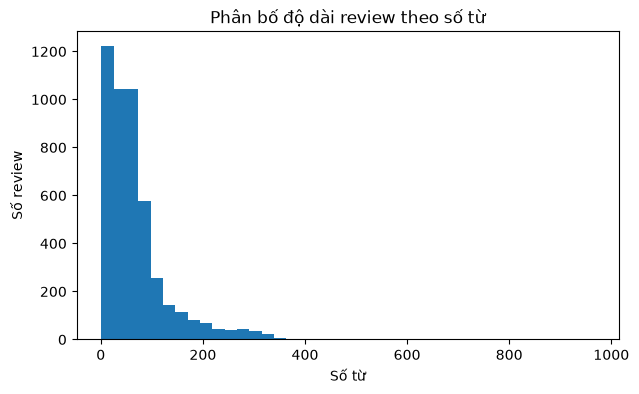

In [5]:
if text_col is not None:
    text_series = df[text_col].fillna("").astype(str)
    length_df = pd.DataFrame({
        "num_chars": text_series.str.len(),
        "num_words": text_series.str.split().apply(len),
    })
    display(length_df.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T)

    ax = length_df["num_words"].plot(kind="hist", bins=40, figsize=(7, 4))
    ax.set_title("Phân bố độ dài review theo số từ")
    ax.set_xlabel("Số từ")
    ax.set_ylabel("Số review")
    plt.show()

## 6. Phân bố aspect được nhắc tới

Ở bài toán ABSA, một review có thể chứa nhiều aspect
Biểu đồ dưới đây cho thấy aspect nào phổ biến, aspect nào hiếm - đây là nguyên nhân chính gây mất cân bằng dữ liệu

,aspect,none,positive,negative,neutral,mentioned,mention_rate
5,FOOD#QUALITY,476,3745,92,438,4275,0.899811
6,FOOD#STYLE&OPTIONS,2086,2272,154,239,2665,0.560935
4,FOOD#PRICES,2295,1203,210,1043,2456,0.516944
8,RESTAURANT#GENERAL,3442,1213,55,41,1309,0.275521
11,SERVICE#GENERAL,3553,920,164,114,1198,0.252157
0,AMBIENCE#GENERAL,3554,843,151,203,1197,0.251947
7,LOCATION#GENERAL,4065,221,95,370,686,0.144391
9,RESTAURANT#MISCELLANEOUS,4353,183,62,153,398,0.083772
10,RESTAURANT#PRICES,4380,226,30,115,371,0.078089
2,DRINKS#QUALITY,4527,176,21,27,224,0.047148


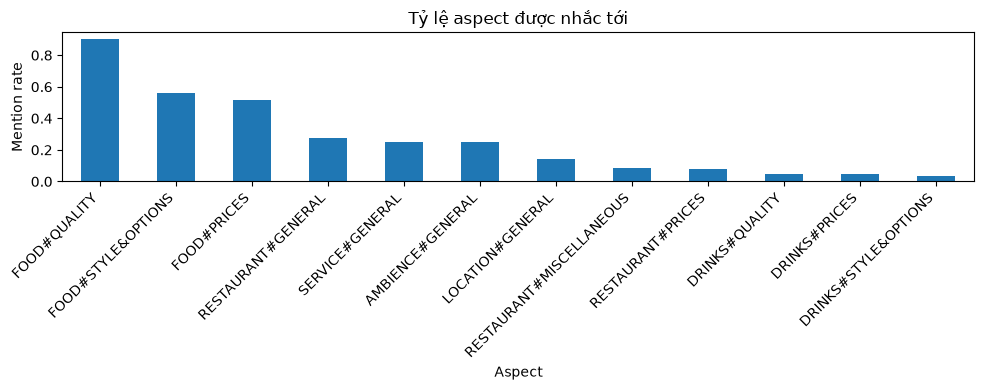

In [6]:
if aspect_cols:
    aspect_stats = []
    for aspect in aspect_cols:
        counts = df[aspect].fillna(0).astype(int).value_counts().to_dict()
        mentioned = len(df) - counts.get(0, 0)
        aspect_stats.append({
            "aspect": aspect,
            "none": counts.get(0, 0),
            "positive": counts.get(1, 0),
            "negative": counts.get(2, 0),
            "neutral": counts.get(3, 0),
            "mentioned": mentioned,
            "mention_rate": mentioned / len(df),
        })

    aspect_stats_df = pd.DataFrame(aspect_stats).sort_values("mention_rate", ascending=False)
    display(aspect_stats_df)

    ax = aspect_stats_df.plot(x="aspect", y="mention_rate", kind="bar", legend=False, figsize=(10, 4))
    ax.set_title("Tỷ lệ aspect được nhắc tới")
    ax.set_xlabel("Aspect")
    ax.set_ylabel("Mention rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 7. Phân bố polarity theo từng aspect

Ta cần xem aspect có xuất hiện và sentiment `positive / negative / neutral` có cân bằng không, để từ đó lựa chọn các thuật toán máy học và phương pháp đánh giá mô hình phù hợp

label,negative,neutral,none,positive
aspect,,,,
AMBIENCE#GENERAL,151,203,3554,843
DRINKS#PRICES,18,90,4529,114
DRINKS#QUALITY,21,27,4527,176
DRINKS#STYLE&OPTIONS,8,6,4593,144
FOOD#PRICES,210,1043,2295,1203
FOOD#QUALITY,92,438,476,3745
FOOD#STYLE&OPTIONS,154,239,2086,2272
LOCATION#GENERAL,95,370,4065,221
RESTAURANT#GENERAL,55,41,3442,1213


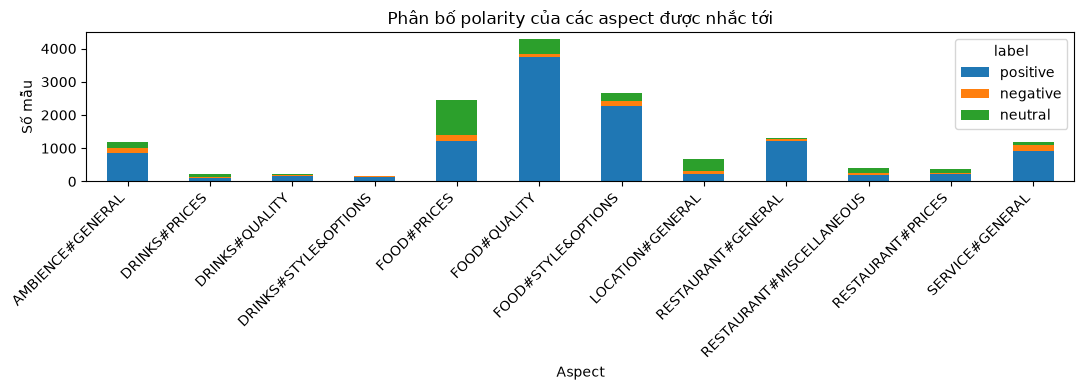

In [7]:
if aspect_cols:
    polarity_rows = []
    for aspect in aspect_cols:
        vc = df[aspect].fillna(0).astype(int).map(LABEL_NAMES).value_counts()
        for label in ["none", "positive", "negative", "neutral"]:
            polarity_rows.append({
                "aspect": aspect,
                "label": label,
                "count": int(vc.get(label, 0)),
            })
    polarity_df = pd.DataFrame(polarity_rows)
    pivot = polarity_df.pivot(index="aspect", columns="label", values="count").fillna(0).astype(int)
    display(pivot)

    mentioned_pivot = pivot[["positive", "negative", "neutral"]].copy()
    ax = mentioned_pivot.plot(kind="bar", stacked=True, figsize=(11, 4))
    ax.set_title("Phân bố polarity của các aspect được nhắc tới")
    ax.set_xlabel("Aspect")
    ax.set_ylabel("Số mẫu")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 8. Từ/cụm từ xuất hiện nhiều trong review

Mục này giúp kiểm tra nhanh miền dữ liệu: review nhà hàng thường xoay quanh món ăn, phục vụ, giá, không gian, vị trí

,token,count
0,ăn,8578
1,ngon,4863
2,quán,3135
3,nước,2301
4,bánh,2285
5,món,2128
6,thịt,1882
7,giá,1858
8,luôn,1858
9,nhiều,1796


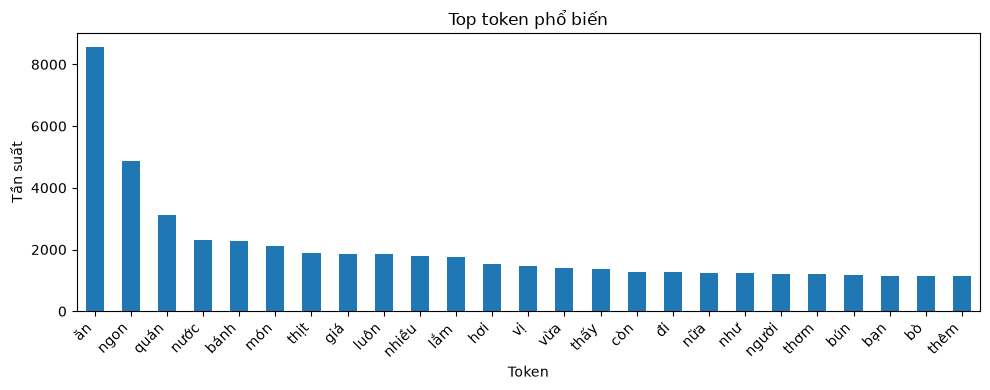

In [8]:
BASIC_STOPWORDS = {
    "và", "là", "có", "của", "cho", "mình", "mình", "thì", "mà", "này",
    "ở", "đây", "rất", "quá", "cũng", "khá", "với", "nhưng", "nên",
    "được", "không", "ko", "k", "một", "các", "những", "đã"
}

def simple_tokens(text: str) -> list[str]:
    return re.findall(r"[\wÀ-ỹà-ỹ_]+", str(text).lower())

if text_col is not None:
    counter = Counter()
    for text in df[text_col].dropna().astype(str):
        for tok in simple_tokens(text):
            if len(tok) >= 2 and tok not in BASIC_STOPWORDS:
                counter[tok] += 1

    top_tokens = pd.DataFrame(counter.most_common(25), columns=["token", "count"])
    display(top_tokens)

    ax = top_tokens.plot(x="token", y="count", kind="bar", legend=False, figsize=(10, 4))
    ax.set_title("Top token phổ biến")
    ax.set_xlabel("Token")
    ax.set_ylabel("Tần suất")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 9. Nhận xét

Từ các thống kê trên có thể rút ra:

1. Đây là bài toán **multi-aspect multi-polarity**, không chỉ là sentiment classification đơn giản
2. Lớp `none` xuất hiện rất nhiều ở hầu hết aspect, gây mất cân bằng dữ liệu nên cần có phương pháp xử lý phù hợp nhằm cải thiện model
3. Một số aspect như `FOOD#QUALITY`, `SERVICE#GENERAL`, `FOOD#PRICES` thường gặp hơn các aspect hiếm như `DRINKS#PRICES`
4. Vì dữ liệu mất cân bằng, model cần:
   - loss có trọng số
   - threshold riêng cho từng aspect
   - Được đánh giá bằng Aspect F1 và Aspect+Polarity F1 và Macro F1, không chỉ accuracy